Movies Dataset Shape: (9742, 3)
Ratings Dataset Shape: (100836, 4)

Movies
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Ratings
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Merged Dataset Shape: (100836, 6)

User-Movie Matrix Shape: (610, 9719)

Movie Similarity Ma

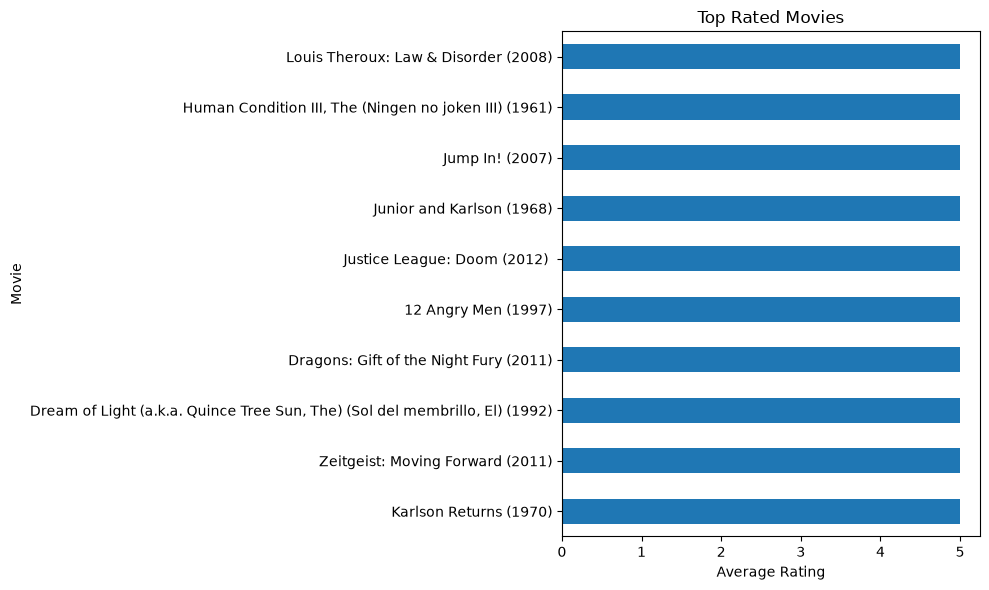

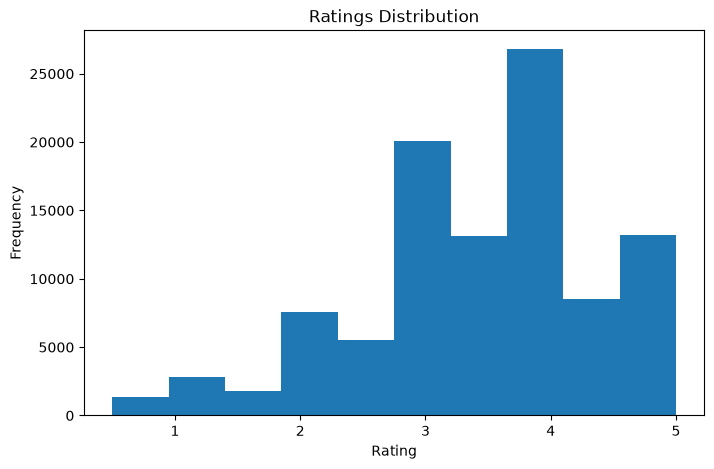

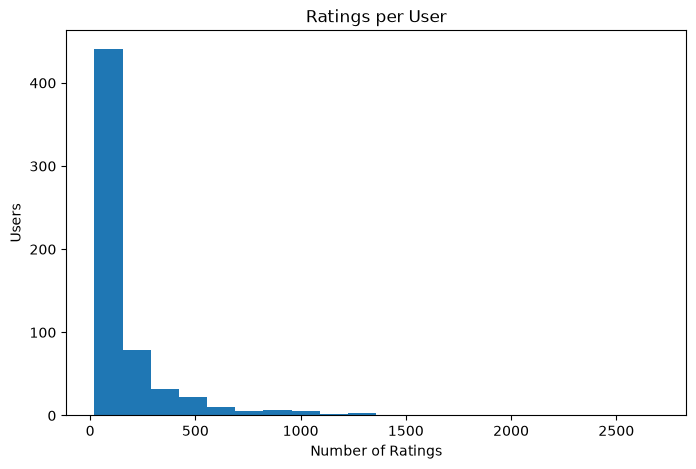


Top 10 Recommendations for 'Star Wars: Episode IV - A New Hope (1977)':

1. Star Wars: Episode V - The Empire Strikes Back (1980)  |  Similarity Score: 0.832
2. Star Wars: Episode VI - Return of the Jedi (1983)  |  Similarity Score: 0.791
3. Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)  |  Similarity Score: 0.709
4. Matrix, The (1999)  |  Similarity Score: 0.663
5. Indiana Jones and the Last Crusade (1989)  |  Similarity Score: 0.642
6. Back to the Future (1985)  |  Similarity Score: 0.623
7. Star Wars: Episode I - The Phantom Menace (1999)  |  Similarity Score: 0.604
8. Terminator, The (1984)  |  Similarity Score: 0.597
9. Godfather, The (1972)  |  Similarity Score: 0.595
10. Saving Private Ryan (1998)  |  Similarity Score: 0.593

Top 10 Recommendations for 'Forrest Gump (1994)':

1. Shawshank Redemption, The (1994)  |  Similarity Score: 0.713
2. Jurassic Park (1993)  |  Similarity Score: 0.688
3. Pulp Fiction (1994)  |  Similarity Score: 0.686
4. Br

In [1]:
# ==========================================================
# TASK 4 - MOVIE RECOMMENDATION SYSTEM
# Author: Jomin S George
# ==========================================================

# ==========================
# Import Libraries
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

# ==========================
# Load Dataset
# ==========================

movies = pd.read_csv("dataset/movies.csv")
ratings = pd.read_csv("dataset/ratings.csv")

print("Movies Dataset Shape:", movies.shape)
print("Ratings Dataset Shape:", ratings.shape)

print("\nMovies")
print(movies.head())

print("\nRatings")
print(ratings.head())

# ==========================
# Merge Datasets
# ==========================

data = pd.merge(ratings, movies, on="movieId")

print("\nMerged Dataset Shape:", data.shape)

# ==========================
# Create User-Movie Matrix
# ==========================

user_movie_matrix = data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

print("\nUser-Movie Matrix Shape:", user_movie_matrix.shape)

# Fill missing ratings with 0
user_movie_matrix = user_movie_matrix.fillna(0)

# ==========================
# Compute Movie Similarity
# ==========================

movie_similarity = cosine_similarity(user_movie_matrix.T)

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

print("\nMovie Similarity Matrix Created Successfully!")

# ==========================
# Recommendation Function
# ==========================

def recommend_movies(movie_name, num_recommendations=10):

    if movie_name not in movie_similarity_df.columns:
        print("Movie not found in dataset.")
        return

    similar_movies = movie_similarity_df[movie_name].sort_values(
        ascending=False
    )[1:num_recommendations+1]

    print(f"\nTop {num_recommendations} Recommendations for '{movie_name}':\n")

    for i, (movie, score) in enumerate(similar_movies.items(), start=1):
        print(f"{i}. {movie}  |  Similarity Score: {score:.3f}")

# ==========================
# Test Recommendation
# ==========================

recommend_movies("Toy Story (1995)")

# ==========================
# Top Rated Movies
# ==========================

top_movies = (
    data.groupby("title")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop Rated Movies\n")
print(top_movies)

# ==========================
# Plot Top Rated Movies
# ==========================

plt.figure(figsize=(10,6))

top_movies.sort_values().plot(kind="barh")

plt.title("Top Rated Movies")

plt.xlabel("Average Rating")

plt.ylabel("Movie")

plt.tight_layout()

plt.show()

# ==========================
# Ratings Distribution
# ==========================

plt.figure(figsize=(8,5))

plt.hist(data["rating"], bins=10)

plt.title("Ratings Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

# ==========================
# User Activity
# ==========================

user_activity = ratings.groupby("userId").size()

plt.figure(figsize=(8,5))

plt.hist(user_activity, bins=20)

plt.title("Ratings per User")

plt.xlabel("Number of Ratings")

plt.ylabel("Users")

plt.show()

# ==========================
# Example Recommendations
# ==========================

recommend_movies("Star Wars: Episode IV - A New Hope (1977)")

recommend_movies("Forrest Gump (1994)")

recommend_movies("Matrix, The (1999)")

print("\nTask Completed Successfully!")